# ALLaM-7B on Kaggle dual T4: controlled `kaggle-vllm==0.2.0` characterization

**Research notebook / systems characterization — not a reproduction of ALLaM training or benchmark-quality claims.**

This notebook levels up the successful `p2-allam-7b-instruct-kaggle-vllm` compatibility run into a controlled systems study of:

- `humain-ai/ALLaM-7B-Instruct-preview`
- immutable checkpoint `a28dd1e67420cde72d3629c8633a974cf7d9c366`
- `kaggle-vllm==0.2.0`
- the SDK's staged upstream vLLM runtime built from upstream v0.18.1
- Kaggle **2 × Tesla T4 / SM75**
- vLLM **TRITON_ATTN** on Turing
- FP16 deployment of the checkpoint
- tensor parallelism **TP=1 vs TP=2**
- configured context **2048 vs 4096**
- repeated fixed-token workloads
- latency / TTFT / TPOT where vLLM request metrics are available
- output throughput
- GPU-memory / utilization telemetry
- offline scheduler concurrency scaling
- Arabic/English tokenizer-fertility diagnostics
- bilingual and multi-turn correctness smoke tests
- checksummed evidence

## Why these experiments follow the ALLaM paper

The ALLaM paper emphasizes several properties that directly motivate inference-system experiments:

1. **Arabic tokenizer efficiency matters.** The paper's Figure 3 and tokenizer discussion connect high tokenizer fertility with more tokens per word, inefficient inference, and reduced effective context length.
2. **ALLaM is bilingual.** Its pretraining and alignment intentionally preserve English while acquiring Arabic.
3. **Multi-turn alignment matters.** The paper describes multi-turn SFT data and turn augmentation.
4. **The original training stack differs radically from Kaggle T4 inference.** The paper used 128–1024 A100 GPUs, InfiniBand, Megatron-LM data/tensor/pipeline parallelism, FlashAttention and BF16. This notebook does **not** try to reproduce that training stack. It studies a constrained deployment path on dual T4, where the previously validated run selected Triton attention and cast BF16 weights to FP16.
5. **Evaluation should be multi-dimensional.** The paper combines automatic, LLM-based and human evaluation. This notebook stays deliberately on the **systems** side: capacity, latency, throughput, memory and bilingual tokenization. It does not claim to reproduce MMLU, ACVA, MT-Bench, human preference, or safety results.

## Core hypotheses

- **H1 — capacity:** TP=2 should provide more memory headroom than TP=1 for a 7B FP16 model on 14.56-GiB T4s.
- **H2 — TP overhead:** TP=2 is not assumed to be faster. At low concurrency, communication may offset partitioned compute.
- **H3 — context:** the checkpoint advertises a 4096-token context; 4096 is tested separately from the already validated 2048 path.
- **H4 — concurrency:** scheduler batching can change throughput; measure rather than assume a crossover.
- **H5 — tokenization:** Arabic and English word-level workloads can have different token costs, so both word-normalized and token-normalized views are useful.
- **H6 — repeatability:** results should be based on repeated runs and persist raw evidence rather than a single generation.

### Runtime note

A full matrix initializes up to four engines (`TP ∈ {1,2}` × `context ∈ {2048,4096}`) in isolated child processes. On T4 this can take tens of minutes. Failed configurations are retained as evidence and classified rather than crashing the notebook.

In [12]:
# ============================================================
# STEP 0 — FINAL characterization matrix
# ============================================================

from pathlib import Path
import csv
import hashlib
import json
import math
import os
import re
import signal
import statistics
import subprocess
import sys
import threading
import time


MODEL_ID = "humain-ai/ALLaM-7B-Instruct-preview"

MODEL_COMMIT = (
    "a28dd1e67420cde72d3629c8633a974cf7d9c366"
)

EXPECTED_INTERNAL_VERSION = (
    "7b-alpha-v2.33.0.30"
)

SDK_VERSION = "0.2.0"


# ------------------------------------------------------------
# Runtime paths
# ------------------------------------------------------------

RUNTIME_ROOT = Path(
    "/kaggle/working/kaggle-vllm-allam-020"
)

STAGED = RUNTIME_ROOT / "vllm-staged"
OVERLAY = RUNTIME_ROOT / "vllm-runtime-overlay"
MANIFEST = RUNTIME_ROOT / "kaggle-vllm-runtime.json"

CACHE = Path(
    "/kaggle/working/kaggle-vllm-cache"
)

MODEL_CACHE = Path(
    "/kaggle/working/hf-allam-cache"
)

RESEARCH_ROOT = Path(
    "/kaggle/working/allam-characterization"
)

RUNS_DIR = RESEARCH_ROOT / "runs"
EVIDENCE_DIR = RESEARCH_ROOT / "evidence"
PLOTS_DIR = RESEARCH_ROOT / "plots"

RUNNER_PATH = (
    RESEARCH_ROOT
    / "allam_characterization_runner.py"
)

for d in (
    RESEARCH_ROOT,
    RUNS_DIR,
    EVIDENCE_DIR,
    PLOTS_DIR,
):
    d.mkdir(
        parents=True,
        exist_ok=True,
    )


# ============================================================
# FINAL MATRIX
#
# 960 is below vLLM's measured single-T4 max estimate (976).
#
# 2048/4096 TP=1 are intentionally retained as
# resource-capacity boundary observations.
# ============================================================

MATRIX = [

    {
        "tp": 1,
        "max_model_len": 960,
        "gpu_memory_utilization": 0.98,
        "experiment_role":
            "single_t4_feasibility_probe",
    },

    {
        "tp": 2,
        "max_model_len": 960,
        "gpu_memory_utilization": 0.85,
        "experiment_role":
            "matched_tp2_960_baseline",
    },

    {
        "tp": 1,
        "max_model_len": 2048,
        "gpu_memory_utilization": 0.98,
        "experiment_role":
            "single_t4_capacity_boundary",
    },

    {
        "tp": 1,
        "max_model_len": 4096,
        "gpu_memory_utilization": 0.98,
        "experiment_role":
            "single_t4_capacity_boundary",
    },

    {
        "tp": 2,
        "max_model_len": 2048,
        "gpu_memory_utilization": 0.85,
        "experiment_role":
            "validated_dual_t4_baseline",
    },

    {
        "tp": 2,
        "max_model_len": 4096,
        "gpu_memory_utilization": 0.85,
        "experiment_role":
            "dual_t4_full_context",
    },
]


# ------------------------------------------------------------
# Benchmark protocol
# ------------------------------------------------------------

REPEATS = 3

CORE_PROMPT_TOKENS = 128
CORE_OUTPUT_TOKENS = 32

CAPACITY_OUTPUT_TOKENS = 32
CAPACITY_MARGIN_TOKENS = 64

CONCURRENCY_LEVELS = [
    1,
    2,
    4,
    8,
]

CONCURRENCY_PROMPT_TOKENS = 128
CONCURRENCY_OUTPUT_TOKENS = 16

ENGINE_TIMEOUT_SECONDS = 1500

REUSE_EXISTING_PASS_RESULTS = True

print("Final matrix:")

for spec in MATRIX:

    print(
        f"TP={spec['tp']} "
        f"context={spec['max_model_len']} "
        f"gpu_util={spec['gpu_memory_utilization']:.2f} "
        f"role={spec['experiment_role']}"
    )

Final matrix:
TP=1 context=960 gpu_util=0.98 role=single_t4_feasibility_probe
TP=2 context=960 gpu_util=0.85 role=matched_tp2_960_baseline
TP=1 context=2048 gpu_util=0.98 role=single_t4_capacity_boundary
TP=1 context=4096 gpu_util=0.98 role=single_t4_capacity_boundary
TP=2 context=2048 gpu_util=0.85 role=validated_dual_t4_baseline
TP=2 context=4096 gpu_util=0.85 role=dual_t4_full_context


## 1. Hardware-health gate

The preceding development run exposed an important experimental-control issue: a Kaggle allocation can fail for a **hardware/session** reason such as an uncorrectable ECC event. A systems benchmark should reject a sick allocation before interpreting the failure as a model/runtime result.

This gate tests each physical T4 in its own subprocess. CUDA is therefore not initialized in the notebook process that later launches vLLM.

In [2]:
# ============================================================
# STEP 1 — Fresh dual-T4 health preflight
# ============================================================

print("GPU inventory:")
subprocess.run(["nvidia-smi", "-L"], check=True)

print("\nECC summary:")
subprocess.run(["nvidia-smi", "-q", "-d", "ECC"], check=False)

GPU_TEST = r"""
import torch
assert torch.cuda.is_available()
assert torch.cuda.device_count() == 1
p = torch.cuda.get_device_properties(0)
print("GPU", p.name, "SM", f"{p.major}{p.minor}")
x = torch.ones((2048, 2048), device="cuda", dtype=torch.float16)
y = x @ x
torch.cuda.synchronize()
print("checksum", float(y[0,0].item()))
print("GPU_HEALTH_PASS")
"""

health = []
for physical_gpu in (0, 1):
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = str(physical_gpu)
    p = subprocess.run(
        [sys.executable, "-c", GPU_TEST],
        capture_output=True,
        text=True,
        env=env,
    )
    print(f"\n--- physical GPU {physical_gpu} ---")
    print(p.stdout)
    if p.stderr.strip():
        print(p.stderr)
    combined = (p.stdout + "\n" + p.stderr).lower()
    ok = (
        p.returncode == 0
        and "gpu_health_pass" in combined
        and "uncorrectable ecc" not in combined
        and "cuda error" not in combined
    )
    health.append(ok)

if not all(health):
    raise RuntimeError(
        "GPU health preflight failed. Stop this Kaggle GPU session and request "
        "a fresh T4×2 allocation before running the research matrix."
    )

print("\nGPU HEALTH PREFLIGHT: PASS")

GPU inventory:
GPU 0: Tesla T4 (UUID: GPU-0d9dd885-261d-52c4-fa74-36143a6ac0d2)
GPU 1: Tesla T4 (UUID: GPU-2a3d969b-0900-044a-3a6a-9da42cb198d2)

ECC summary:

==============NVSMI LOG==============

Timestamp                                              : Thu Oct  1 10:16:09 2026
Driver Version                                         : 580.159.04
CUDA Version                                           : 13.0

Attached GPUs                                          : 2
GPU 00000000:00:04.0
    ECC Mode
        Current                                        : Enabled
        Pending                                        : Enabled
    ECC Errors
        Volatile
            SRAM Correctable                           : 0
            SRAM Uncorrectable                         : 0
            DRAM Correctable                           : 0
            DRAM Uncorrectable                         : 0
        Aggregate
            SRAM Correctable                           : 0
            SRAM Unc

## 2. Install and strictly validate `kaggle-vllm==0.2.0`

This retains the compatibility discipline of the successful `p2` run:

- install only the lightweight SDK;
- stage its immutable native vLLM wheel;
- keep the dependency overlay separate;
- preserve Kaggle's PyTorch/CUDA installation;
- verify native vLLM modules;
- run the strict doctor profile.

In [3]:
# ============================================================
# STEP 2A — Install SDK
# ============================================================

torch_before = subprocess.check_output(
    [
        sys.executable,
        "-c",
        "import torch; print(torch.__version__, torch.version.cuda, torch.__file__)",
    ],
    text=True,
).strip()
print("Torch before:", torch_before)

subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--no-cache-dir",
        f"kaggle-vllm[hub]=={SDK_VERSION}",
    ],
    check=True,
)

import kaggle_vllm
assert kaggle_vllm.__version__ == SDK_VERSION
print("kaggle-vllm:", kaggle_vllm.__version__)

Torch before: 2.10.0+cu128 12.8 /usr/local/lib/python3.12/dist-packages/torch/__init__.py
kaggle-vllm: 0.2.0


In [4]:
# ============================================================
# STEP 2B — Bootstrap / activate / doctor
# ============================================================

if not MANIFEST.is_file():
    if STAGED.exists() or OVERLAY.exists():
        raise RuntimeError(
            "Partial runtime state exists without a completed manifest. "
            "Use a fresh Kaggle session or change RUNTIME_ROOT."
        )

    RUNTIME_ROOT.mkdir(parents=True, exist_ok=True)
    CACHE.mkdir(parents=True, exist_ok=True)

    bootstrap_cmd = [
        "kaggle-vllm",
        "bootstrap",
        "--strict",
        "--cache", str(CACHE),
        "--staged", str(STAGED),
        "--overlay", str(OVERLAY),
        "--manifest", str(MANIFEST),
    ]
    subprocess.run(bootstrap_cmd + ["--dry-run", "--json"], check=True)
    subprocess.run(bootstrap_cmd, check=True)
else:
    print("Reusing completed manifest:", MANIFEST)

assert MANIFEST.is_file()
os.environ["KAGGLE_VLLM_MANIFEST"] = str(MANIFEST)

from kaggle_vllm import activate_runtime
assert activate_runtime(MANIFEST)

import vllm
import vllm._C
import vllm._moe_C
import vllm.cumem_allocator

print("vLLM distribution:", getattr(vllm, "__version__", "unknown"))
print("vLLM path:", vllm.__file__)

doctor_path = EVIDENCE_DIR / "kaggle-vllm-doctor.json"
doctor_env = os.environ.copy()
doctor_env["KAGGLE_VLLM_MANIFEST"] = str(MANIFEST)

with doctor_path.open("w", encoding="utf-8") as f:
    doctor_proc = subprocess.run(
        ["kaggle-vllm", "doctor", "--strict", "--json"],
        stdout=f,
        stderr=subprocess.STDOUT,
        text=True,
        env=doctor_env,
    )

doctor_text = doctor_path.read_text(encoding="utf-8", errors="replace")
print(doctor_text)
if doctor_proc.returncode != 0:
    raise RuntimeError("Strict kaggle-vllm doctor failed.")

torch_after = subprocess.check_output(
    [
        sys.executable,
        "-c",
        (
            "import os; "
            f"os.environ['KAGGLE_VLLM_MANIFEST']={str(MANIFEST)!r}; "
            "from kaggle_vllm import activate_runtime; "
            "assert activate_runtime(os.environ['KAGGLE_VLLM_MANIFEST']); "
            "import torch; print(torch.__version__, torch.version.cuda, torch.__file__)"
        ),
    ],
    text=True,
).strip()

print("Torch before:", torch_before)
print("Torch after :", torch_after)
assert torch_before.split()[:2] == torch_after.split()[:2]
print("STEP 2: PASS")

{
  "profile": "kaggle-t4x2-cu128",
  "strict": true,
  "compatible": true,
  "findings": [
    {
      "check": "Python implementation",
      "status": "pass",
      "message": "Python implementation: CPython"
    },
    {
      "check": "Python ABI",
      "status": "pass",
      "message": "Python ABI: cp312"
    },
    {
      "check": "operating system",
      "status": "pass",
      "message": "operating system: Linux"
    },
    {
      "check": "machine",
      "status": "pass",
      "message": "machine: x86_64"
    },
    {
      "check": "Kaggle runtime",
      "status": "pass",
      "message": "Kaggle runtime: True"
    },
    {
      "check": "PyTorch",
      "status": "pass",
      "message": "PyTorch: 2.10.0+cu128"
    },
    {
      "check": "PyTorch CUDA",
      "status": "pass",
      "message": "PyTorch CUDA: 12.8"
    },
    {
      "check": "visible GPU count",
      "status": "pass",
      "message": "visible GPU count: 2"
    },
    {
      "check": "GPU model"

## 3. Pin the same immutable ALLaM checkpoint that passed `p2`

The earlier successful run established a concrete provenance anchor. This notebook deliberately **does not follow a moving `main` branch**. It uses the exact checkpoint SHA that already produced successful bilingual TP=2 inference.

The checkpoint configuration is validated before any benchmark claims are made.

In [5]:
# ============================================================
# STEP 3 — Download immutable ALLaM snapshot
# ============================================================

from huggingface_hub import snapshot_download

MODEL_CACHE.mkdir(parents=True, exist_ok=True)

model_path = Path(
    snapshot_download(
        repo_id=MODEL_ID,
        revision=MODEL_COMMIT,
        cache_dir=str(MODEL_CACHE),
        token=os.environ.get("HF_TOKEN") or None,
    )
).resolve()

config_path = model_path / "config.json"
assert config_path.is_file()

config = json.loads(config_path.read_text(encoding="utf-8"))

expected = {
    "model_type": "llama",
    "hidden_size": 4096,
    "num_hidden_layers": 32,
    "num_attention_heads": 32,
    "num_key_value_heads": 32,
    "max_position_embeddings": 4096,
}
for k, v in expected.items():
    assert config.get(k) == v, (k, config.get(k), v)

assert "LlamaForCausalLM" in (config.get("architectures") or [])
assert config.get("internal_version") == EXPECTED_INTERNAL_VERSION

print("Model path:", model_path)
print("Commit:", MODEL_COMMIT)
print("Internal version:", config.get("internal_version"))
print("Source dtype:", config.get("torch_dtype"))
print("Advertised max context:", config.get("max_position_embeddings"))

Fetching 466 files:   0%|          | 0/466 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/686 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

ar_ifeval_0_shot.json: 0.00B [00:00, ?B/s]

araMath_v3_5_shot.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.03G [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Model path: /kaggle/working/hf-allam-cache/models--humain-ai--ALLaM-7B-Instruct-preview/snapshots/a28dd1e67420cde72d3629c8633a974cf7d9c366
Commit: a28dd1e67420cde72d3629c8633a974cf7d9c366
Internal version: 7b-alpha-v2.33.0.30
Source dtype: bfloat16
Advertised max context: 4096


## 4. Paper-derived tokenizer-fertility diagnostic

The paper explicitly argues that poor Arabic tokenization inflates token counts and reduces effective context. Figure 3 compares tokenizer fertility across English, Arabic and code; Section 2.2 links excessive tokenization to inefficient inference and shorter effective context.

Here we do **not** try to reproduce the paper's corpus-level fertility numbers. Instead, we record a small, transparent diagnostic on fixed English, Arabic and code passages using the exact deployed checkpoint tokenizer.

Metrics:

- `tokens`
- whitespace-delimited `words` (a simple operational proxy, not an Arabic morphological analysis)
- `tokens_per_word`
- `chars_per_token`

This provides context for later token-normalized benchmarks.

In [6]:
# ============================================================
# STEP 4 — Tokenizer fertility diagnostic (CPU only)
# ============================================================

from transformers import AutoTokenizer
import pandas as pd

tokenizer_cpu = AutoTokenizer.from_pretrained(
    model_path,
    local_files_only=True,
    use_fast=True,
)

FERTILITY_SAMPLES = {
    "english": (
        "Artificial intelligence systems should answer clearly, preserve context, "
        "and explain technical ideas with accurate evidence. Efficient tokenization "
        "reduces the amount of computation required for a fixed amount of text."
    ),
    "arabic": (
        "يجب أن تجيب أنظمة الذكاء الاصطناعي بوضوح، وأن تحافظ على السياق، "
        "وأن تشرح الأفكار التقنية بأدلة دقيقة. يساعد الترميز الفعال على تقليل "
        "عدد الرموز المطلوبة لتمثيل كمية ثابتة من النص."
    ),
    "code": (
        "def benchmark(model, prompts):\n"
        "    results = model.generate(prompts)\n"
        "    return {'requests': len(results), 'status': 'ok'}\n"
    ),
}

fertility_rows = []
for language, text in FERTILITY_SAMPLES.items():
    token_ids = tokenizer_cpu.encode(text, add_special_tokens=False)
    words = len(text.split())
    chars = len(text)
    fertility_rows.append(
        {
            "sample": language,
            "words": words,
            "chars": chars,
            "tokens": len(token_ids),
            "tokens_per_word": round(len(token_ids) / max(words, 1), 4),
            "chars_per_token": round(chars / max(len(token_ids), 1), 4),
        }
    )

fertility_df = pd.DataFrame(fertility_rows)
display(fertility_df)

fertility_path = EVIDENCE_DIR / "tokenizer-fertility.json"
fertility_path.write_text(
    json.dumps(fertility_rows, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)
print("Saved:", fertility_path)

,sample,words,chars,tokens,tokens_per_word,chars_per_token
0,english,29,218,36,1.2414,6.0556
1,arabic,30,179,37,1.2333,4.8378
2,code,11,123,43,3.9091,2.8605


Saved: /kaggle/working/allam-characterization/evidence/tokenizer-fertility.json


## 5. Bilingual / multi-turn correctness sanity check

The research paper's alignment section stresses bilingual instruction following and multi-turn data. Systems throughput is meaningless if the model is not being prompted through its intended chat template.

This is a **small sanity check only**. It is not an MT-Bench, MMLU, ACVA, safety, cultural-alignment or human-preference reproduction. The heavier matrix that follows uses exact token IDs for controlled systems measurements.

In [7]:
# ============================================================
# STEP 5 — Prepare bilingual chat-template prompts
# ============================================================

BILINGUAL_CONVERSATIONS = [
    [
        {"role": "user", "content": "Who are you? Answer in one concise sentence."},
    ],
    [
        {"role": "user", "content": "من أنت؟ أجب بجملة واحدة مختصرة."},
    ],
    [
        {"role": "user", "content": "Explain what tensor parallelism means in one sentence."},
        {"role": "assistant", "content": "Tensor parallelism splits model tensor operations across multiple accelerators."},
        {"role": "user", "content": "Now give one reason it can be slower for small workloads."},
    ],
    [
        {"role": "user", "content": "اشرح معنى التوازي على مستوى المصفوفات في جملة واحدة."},
        {"role": "assistant", "content": "يقسم التوازي عمليات النموذج بين عدة معالجات رسومية."},
        {"role": "user", "content": "اذكر الآن سبباً واحداً قد يجعله أبطأ في الأحمال الصغيرة."},
    ],
]

for i, messages in enumerate(BILINGUAL_CONVERSATIONS):
    rendered = tokenizer_cpu.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    ids = tokenizer_cpu.encode(rendered, add_special_tokens=False)
    print(f"\nConversation {i}: {len(ids)} tokens")
    print(rendered[:800])


Conversation 0: 19 tokens
<s> [INST] Who are you? Answer in one concise sentence. [/INST]

Conversation 1: 17 tokens
<s> [INST] من أنت؟ أجب بجملة واحدة مختصرة. [/INST]

Conversation 2: 55 tokens
<s> [INST] Explain what tensor parallelism means in one sentence. [/INST] Tensor parallelism splits model tensor operations across multiple accelerators. </s><s> [INST] Now give one reason it can be slower for small workloads. [/INST]

Conversation 3: 56 tokens
<s> [INST] اشرح معنى التوازي على مستوى المصفوفات في جملة واحدة. [/INST] يقسم التوازي عمليات النموذج بين عدة معالجات رسومية. </s><s> [INST] اذكر الآن سبباً واحداً قد يجعله أبطأ في الأحمال الصغيرة. [/INST]


## 6. Generic isolated characterization runner

Each `(TP, max_model_len)` configuration is run in a **fresh child process** so CUDA/vLLM workers tear down cleanly between configurations.

The runner performs, in order:

1. CPU/model-provenance checks.
2. vLLM engine initialization.
3. engine metadata collection.
4. one warm-up.
5. **core fixed-token workload:** English and Arabic token streams, exact `128 → 32` tokens, repeated `REPEATS` times.
6. **near-context capacity probe:** exact token prompt close to the configured context limit plus 32 forced output tokens.
7. **offline concurrency scaling:** 1/2/4/8 simultaneous scheduler requests at exact `128 → 16` tokens.
8. bilingual + multi-turn chat sanity generation.
9. JSON evidence.

`ignore_eos=True` and `min_tokens=max_tokens` are used for the performance microbenchmarks so output lengths are controlled. Normal EOS behavior is retained for the chat sanity check.

In [8]:
# ============================================================
# STEP 6 — Write generic runner
# ============================================================

RUNNER_SOURCE = '#!/usr/bin/env python3\nfrom __future__ import annotations\n\nimport argparse\nimport json\nimport os\nimport platform\nimport statistics\nimport subprocess\nimport sys\nimport time\nfrom pathlib import Path\n\nos.environ.setdefault("TOKENIZERS_PARALLELISM", "false")\nos.environ.setdefault("VLLM_WORKER_MULTIPROC_METHOD", "spawn")\nos.environ.setdefault("NCCL_DEBUG", "INFO")\nos.environ.setdefault("NCCL_DEBUG_SUBSYS", "INIT,ENV,GRAPH")\n\nfrom kaggle_vllm import KaggleLLM, activate_runtime\n\nmanifest = os.environ.get("KAGGLE_VLLM_MANIFEST")\nif not manifest or not activate_runtime(manifest):\n    raise RuntimeError("kaggle-vllm runtime activation failed")\n\nimport torch\nimport vllm\nfrom vllm import SamplingParams\nfrom vllm.inputs import TokensPrompt\n\n\ndef args():\n    p = argparse.ArgumentParser()\n    p.add_argument("--model", required=True)\n    p.add_argument("--model-commit", required=True)\n    p.add_argument("--expected-internal-version", required=True)\n    p.add_argument("--tp", type=int, required=True)\n    p.add_argument("--max-model-len", type=int, required=True)\n    p.add_argument("--gpu-memory-utilization", type=float, default=0.85)\n    p.add_argument("--repeats", type=int, default=3)\n    p.add_argument("--core-prompt-tokens", type=int, default=128)\n    p.add_argument("--core-output-tokens", type=int, default=32)\n    p.add_argument("--capacity-output-tokens", type=int, default=32)\n    p.add_argument("--capacity-margin-tokens", type=int, default=64)\n    p.add_argument("--concurrency-levels", default="1,2,4,8")\n    p.add_argument("--concurrency-prompt-tokens", type=int, default=128)\n    p.add_argument("--concurrency-output-tokens", type=int, default=16)\n    p.add_argument("--result-json", required=True)\n    return p.parse_args()\n\n\ndef percentile(values, q):\n    values = [float(x) for x in values if x is not None]\n    if not values:\n        return None\n    values = sorted(values)\n    if len(values) == 1:\n        return values[0]\n    pos = (len(values) - 1) * q\n    lo = int(pos)\n    hi = min(lo + 1, len(values) - 1)\n    frac = pos - lo\n    return values[lo] * (1 - frac) + values[hi] * frac\n\n\ndef exact_ids(tokenizer, seed_text, target):\n    base = tokenizer.encode(seed_text, add_special_tokens=False)\n    if not base:\n        raise RuntimeError("seed text tokenized to zero tokens")\n    bos = tokenizer.bos_token_id\n    ids = ([bos] if bos is not None else [])\n    need = target - len(ids)\n    if need < 0:\n        return ids[:target]\n    repeats = (need + len(base) - 1) // len(base)\n    ids.extend((base * repeats)[:need])\n    if len(ids) != target:\n        raise RuntimeError((len(ids), target))\n    return ids\n\n\ndef request_metrics(out, output_tokens):\n    m = getattr(out, "metrics", None)\n    if m is None:\n        return {"ttft_s": None, "e2e_s": None, "tpot_s": None, "queue_s": None}\n    arrival = getattr(m, "arrival_time", None)\n    first = getattr(m, "first_token_time", None)\n    finished = getattr(m, "finished_time", None)\n    queue = getattr(m, "time_in_queue", None)\n    ttft = (first - arrival) if arrival is not None and first is not None else None\n    e2e = (finished - arrival) if arrival is not None and finished is not None else None\n    tpot = None\n    if first is not None and finished is not None and output_tokens > 1:\n        tpot = (finished - first) / (output_tokens - 1)\n    return {"ttft_s": ttft, "e2e_s": e2e, "tpot_s": tpot, "queue_s": queue}\n\n\ndef run_batch(llm, tokenizer, label, language, prompt_tokens, output_tokens, concurrency, repeat):\n    seed = (\n        "Efficient inference requires careful measurement of latency throughput memory and scheduling. "\n        if language == "english"\n        else\n        "يتطلب الاستدلال الفعال قياساً دقيقاً لزمن الاستجابة والإنتاجية والذاكرة والجدولة. "\n    )\n    ids = exact_ids(tokenizer, seed, prompt_tokens)\n    prompts = [TokensPrompt(prompt_token_ids=list(ids)) for _ in range(concurrency)]\n    sp = SamplingParams(\n        temperature=0.0,\n        max_tokens=output_tokens,\n        min_tokens=output_tokens,\n        ignore_eos=True,\n        seed=0,\n    )\n    t0 = time.perf_counter()\n    outs = llm.generate(prompts, sp, use_tqdm=False)\n    wall = time.perf_counter() - t0\n\n    total_prompt = sum(len(o.prompt_token_ids or []) for o in outs)\n    total_output = sum(len(o.outputs[0].token_ids or []) for o in outs)\n    per_req = [request_metrics(o, len(o.outputs[0].token_ids or [])) for o in outs]\n\n    ttft = [x["ttft_s"] for x in per_req if x["ttft_s"] is not None]\n    e2e = [x["e2e_s"] for x in per_req if x["e2e_s"] is not None]\n    tpot = [x["tpot_s"] for x in per_req if x["tpot_s"] is not None]\n    queue = [x["queue_s"] for x in per_req if x["queue_s"] is not None]\n\n    return {\n        "label": label,\n        "language": language,\n        "repeat": repeat,\n        "concurrency": concurrency,\n        "prompt_tokens_per_request": prompt_tokens,\n        "requested_output_tokens_per_request": output_tokens,\n        "request_count": len(outs),\n        "total_prompt_tokens": total_prompt,\n        "total_output_tokens": total_output,\n        "wall_s": wall,\n        "output_tokens_per_s": total_output / wall if wall else None,\n        "total_tokens_per_s": (total_prompt + total_output) / wall if wall else None,\n        "ttft_p50_s": percentile(ttft, 0.50),\n        "ttft_p95_s": percentile(ttft, 0.95),\n        "e2e_p50_s": percentile(e2e, 0.50),\n        "e2e_p95_s": percentile(e2e, 0.95),\n        "tpot_p50_s": percentile(tpot, 0.50),\n        "tpot_p95_s": percentile(tpot, 0.95),\n        "queue_p50_s": percentile(queue, 0.50),\n    }\n\n\ndef main():\n    a = args()\n    model_path = Path(a.model).resolve()\n    result_path = Path(a.result_json).resolve()\n\n    cfg = json.loads((model_path / "config.json").read_text(encoding="utf-8"))\n    if cfg.get("internal_version") != a.expected_internal_version:\n        raise RuntimeError(f"unexpected internal_version={cfg.get(\'internal_version\')!r}")\n    if a.max_model_len > int(cfg.get("max_position_embeddings", 0)):\n        raise RuntimeError("requested max_model_len exceeds checkpoint config")\n\n    print("=" * 72, flush=True)\n    print(f"ALLaM characterization: TP={a.tp} context={a.max_model_len}", flush=True)\n    print("Python:", sys.version.replace("\\n", " "), flush=True)\n    print("Platform:", platform.platform(), flush=True)\n    print("vLLM:", getattr(vllm, "__version__", "unknown"), flush=True)\n    print(subprocess.check_output(["nvidia-smi", "-L"], text=True), flush=True)\n\n    init_t0 = time.perf_counter()\n    llm = KaggleLLM(\n        model=str(model_path),\n        tensor_parallel_size=a.tp,\n        dtype="float16",\n        max_model_len=a.max_model_len,\n        gpu_memory_utilization=a.gpu_memory_utilization,\n        enforce_eager=True,\n        disable_custom_all_reduce=True,\n        trust_remote_code=False,\n        max_num_seqs=max(8, max(int(x) for x in a.concurrency_levels.split(","))),\n    )\n    engine_init_s = time.perf_counter() - init_t0\n    tokenizer = llm.upstream.get_tokenizer()\n\n    # Post-engine CUDA provenance.\n    gpu_records = []\n    for i in range(torch.cuda.device_count()):\n        p = torch.cuda.get_device_properties(i)\n        gpu_records.append(\n            {\n                "index": i,\n                "name": p.name,\n                "compute_capability": f"{p.major}.{p.minor}",\n                "total_memory_gib": round(p.total_memory / 1024**3, 3),\n            }\n        )\n\n    rows = []\n\n    # Warm-up: excluded from summaries.\n    rows.append(\n        run_batch(\n            llm, tokenizer, "warmup", "english",\n            prompt_tokens=64, output_tokens=8, concurrency=1, repeat=0\n        )\n    )\n\n    # Repeated exact-token core workload.\n    for rep in range(1, a.repeats + 1):\n        for language in ("english", "arabic"):\n            rows.append(\n                run_batch(\n                    llm, tokenizer, "core", language,\n                    prompt_tokens=a.core_prompt_tokens,\n                    output_tokens=a.core_output_tokens,\n                    concurrency=1,\n                    repeat=rep,\n                )\n            )\n\n    # Near-context capacity probe.\n    capacity_prompt = a.max_model_len - a.capacity_margin_tokens\n    if capacity_prompt + a.capacity_output_tokens > a.max_model_len:\n        capacity_prompt = a.max_model_len - a.capacity_output_tokens\n    for language in ("english", "arabic"):\n        rows.append(\n            run_batch(\n                llm, tokenizer, "capacity", language,\n                prompt_tokens=capacity_prompt,\n                output_tokens=a.capacity_output_tokens,\n                concurrency=1,\n                repeat=1,\n            )\n        )\n\n    # Offline scheduler concurrency scaling.\n    for c in [int(x) for x in a.concurrency_levels.split(",") if x.strip()]:\n        language = "english" if c % 2 else "arabic"\n        rows.append(\n            run_batch(\n                llm, tokenizer, "concurrency", language,\n                prompt_tokens=a.concurrency_prompt_tokens,\n                output_tokens=a.concurrency_output_tokens,\n                concurrency=c,\n                repeat=1,\n            )\n        )\n\n    # Normal chat sanity (EOS enabled).\n    conversations = [\n        [{"role": "user", "content": "Who are you? Answer in one concise sentence."}],\n        [{"role": "user", "content": "من أنت؟ أجب بجملة واحدة مختصرة."}],\n        [\n            {"role": "user", "content": "What is tensor parallelism? One sentence."},\n            {"role": "assistant", "content": "It partitions tensor operations across accelerators."},\n            {"role": "user", "content": "Why can communication overhead matter? One sentence."},\n        ],\n        [\n            {"role": "user", "content": "ما هو التوازي على مستوى المصفوفات؟ جملة واحدة."},\n            {"role": "assistant", "content": "يقسم العمليات الحسابية بين عدة معالجات."},\n            {"role": "user", "content": "لماذا قد تكون كلفة الاتصال مهمة؟ جملة واحدة."},\n        ],\n    ]\n    chat_prompts = [\n        tokenizer.apply_chat_template(x, tokenize=False, add_generation_prompt=True)\n        for x in conversations\n    ]\n    chat_out = llm.generate(\n        chat_prompts,\n        SamplingParams(temperature=0.0, max_tokens=64, seed=0),\n        use_tqdm=False,\n    )\n    chat_records = []\n    for i, o in enumerate(chat_out):\n        cand = o.outputs[0]\n        chat_records.append(\n            {\n                "index": i,\n                "prompt_tokens": len(o.prompt_token_ids or []),\n                "output_tokens": len(cand.token_ids or []),\n                "finish_reason": getattr(cand, "finish_reason", None),\n                "text": (cand.text or "").strip(),\n            }\n        )\n\n    result = {\n        "status": "PASS",\n        "model_repo": "humain-ai/ALLaM-7B-Instruct-preview",\n        "model_commit": a.model_commit,\n        "internal_version": cfg.get("internal_version"),\n        "sdk": "kaggle-vllm==0.2.0",\n        "vllm_distribution_version": getattr(vllm, "__version__", "unknown"),\n        "torch_version": torch.__version__,\n        "torch_cuda": torch.version.cuda,\n        "tp": a.tp,\n        "max_model_len": a.max_model_len,\n        "dtype": "float16",\n        "gpu_memory_utilization": a.gpu_memory_utilization,\n        "enforce_eager": True,\n        "disable_custom_all_reduce": True,\n        "worker_multiproc_method": os.environ.get("VLLM_WORKER_MULTIPROC_METHOD"),\n        "engine_init_s": engine_init_s,\n        "gpus_visible_to_child": gpu_records,\n        "benchmarks": rows,\n        "chat_sanity": chat_records,\n    }\n\n    result_path.parent.mkdir(parents=True, exist_ok=True)\n    tmp = result_path.with_suffix(result_path.suffix + ".tmp")\n    tmp.write_text(json.dumps(result, ensure_ascii=False, indent=2) + "\\n", encoding="utf-8")\n    tmp.replace(result_path)\n    print("CHARACTERIZATION_PASS", result_path, flush=True)\n\n\nif __name__ == "__main__":\n    main()\n'

RUNNER_PATH.write_text(RUNNER_SOURCE, encoding="utf-8")

syntax = subprocess.run(
    [sys.executable, "-m", "py_compile", str(RUNNER_PATH)],
    capture_output=True,
    text=True,
)
if syntax.returncode != 0:
    print(syntax.stdout)
    print(syntax.stderr)
    raise RuntimeError("runner syntax check failed")

print("Runner:", RUNNER_PATH)
print("Runner syntax: PASS")

Runner: /kaggle/working/allam-characterization/allam_characterization_runner.py
Runner syntax: PASS


## 7. Execute the full TP × context matrix with external GPU telemetry

The notebook process polls `nvidia-smi` while each isolated child runs. This avoids injecting PyTorch CUDA state into the parent while still collecting:

- peak used memory per physical GPU;
- mean and peak GPU utilization;
- ECC state before each configuration;
- engine log evidence.

Result classification:

- `PASS`
- `RESOURCE_GATED` — OOM / insufficient memory / cache-capacity failure
- `HARDWARE_FAULT` — ECC/Xid-style hardware failure
- `FAIL` — other runtime/software error
- `TIMEOUT`

A failed TP=1 configuration is therefore data, not a notebook crash.

In [13]:
# ============================================================
# STEP 7 — FINAL MATRIX DRIVER
#
# Reuses existing compatible evidence.
# Runs only missing configurations.
# Resource-gated configurations are valid results.
# ============================================================

import json
import os
import re
import signal
import statistics
import subprocess
import sys
import threading
import time


# ------------------------------------------------------------
# GPU telemetry
# ------------------------------------------------------------

def poll_gpu_once():

    proc = subprocess.run(
        [
            "nvidia-smi",
            "--query-gpu="
            "index,"
            "uuid,"
            "memory.used,"
            "memory.total,"
            "utilization.gpu,"
            "ecc.errors.uncorrected.volatile.total",
            "--format=csv,noheader,nounits",
        ],
        capture_output=True,
        text=True,
    )

    if proc.returncode != 0:
        return []

    rows = []

    for line in proc.stdout.splitlines():

        parts = [
            x.strip()
            for x in line.split(",")
        ]

        if len(parts) < 6:
            continue


        def as_float(x):

            try:
                return float(x)

            except Exception:
                return None


        rows.append(
            {
                "index":
                    int(parts[0]),

                "uuid":
                    parts[1],

                "memory_used_mib":
                    as_float(parts[2]),

                "memory_total_mib":
                    as_float(parts[3]),

                "utilization_gpu_pct":
                    as_float(parts[4]),

                "volatile_uncorrected_ecc":
                    as_float(parts[5]),
            }
        )

    return rows


# ------------------------------------------------------------
# Failure classification
# ------------------------------------------------------------

def classify_failure(
    log_text,
):

    low = log_text.lower()


    if any(
        s in low
        for s in (
            "uncorrectable ecc",
            "hardware fault",
            "xid ",
        )
    ):

        return "HARDWARE_FAULT"


    if any(
        s in low
        for s in (
            "no available memory for the cache blocks",
            "available kv cache memory",
            "larger than the available kv cache",
            "estimated maximum model length",
            "cuda out of memory",
            "out of memory",
            "insufficient memory",
            "cannot fit",
        )
    ):

        return "RESOURCE_GATED"


    return "FAIL"


def extract_root_cause(
    log_text,
):

    patterns = [

        (
            r"ValueError: To serve at least one request "
            r"with the models?'s max seq len[^\n]*"
        ),

        (
            r"ValueError: No available memory "
            r"for the cache blocks[^\n]*"
        ),

        r"CUDA out of memory[^\n]*",

        r"RuntimeError: NCCL error:[^\n]*",
    ]


    for pattern in patterns:

        matches = re.findall(
            pattern,
            log_text,
            flags=re.IGNORECASE,
        )

        if matches:
            return matches[-1].strip()


    return None


# ------------------------------------------------------------
# Load existing evidence
# ------------------------------------------------------------

matrix_path = (
    EVIDENCE_DIR
    / "matrix-summary.json"
)

existing_by_tag = {}


if matrix_path.is_file():

    try:

        previous = json.loads(
            matrix_path.read_text(
                encoding="utf-8"
            )
        )

        for item in previous:

            tag = item.get("tag")

            if tag:
                existing_by_tag[
                    tag
                ] = item


        print(
            "Existing matrix evidence:"
        )

        for tag, item in (
            existing_by_tag.items()
        ):

            print(
                f"  {tag}: "
                f"{item.get('status')}"
            )


    except Exception as exc:

        print(
            "Could not read previous matrix:",
            repr(exc),
        )

        existing_by_tag = {}


# ============================================================
# Evidence compatibility check
# ============================================================

def existing_gpu_util(
    record,
):

    if not record:
        return None


    # New summary format.
    value = record.get(
        "gpu_memory_utilization"
    )

    if value is not None:
        return float(value)


    # Earlier PASS child-result format.
    child = record.get(
        "child_result"
    )

    if child:

        value = child.get(
            "gpu_memory_utilization"
        )

        if value is not None:
            return float(value)


    return None


def reusable_record(
    existing,
    required_gpu_util,
):

    if not existing:
        return False


    # Both PASS and RESOURCE_GATED are valid experimental
    # outcomes if the exact memory policy is unchanged.
    if existing.get(
        "status"
    ) not in (
        "PASS",
        "RESOURCE_GATED",
    ):

        return False


    old_util = existing_gpu_util(
        existing
    )


    if old_util is None:
        return False


    return (
        abs(
            old_util
            - required_gpu_util
        )
        < 1e-9
    )


# ============================================================
# Run matrix
# ============================================================

matrix_summaries = []


for spec in MATRIX:

    tp = int(
        spec["tp"]
    )

    ctx = int(
        spec["max_model_len"]
    )

    gpu_util = float(
        spec[
            "gpu_memory_utilization"
        ]
    )

    experiment_role = (
        spec.get(
            "experiment_role"
        )
    )

    tag = (
        f"tp{tp}-ctx{ctx}"
    )


    # --------------------------------------------------------
    # Reuse exact compatible evidence
    # --------------------------------------------------------

    old = existing_by_tag.get(
        tag
    )


    if (
        REUSE_EXISTING_PASS_RESULTS
        and reusable_record(
            old,
            gpu_util,
        )
    ):

        reused = dict(
            old
        )

        reused[
            "gpu_memory_utilization"
        ] = gpu_util

        reused[
            "experiment_role"
        ] = experiment_role

        reused[
            "reused_existing_result"
        ] = True


        matrix_summaries.append(
            reused
        )


        print(
            "\n"
            + "=" * 80
        )

        print(
            "REUSE",
            tag,
        )

        print(
            "=" * 80
        )

        print(
            "status:",
            reused[
                "status"
            ],
        )

        print(
            "gpu_memory_utilization:",
            gpu_util,
        )

        continue


    # --------------------------------------------------------
    # Fresh run
    # --------------------------------------------------------

    print(
        "\n"
        + "=" * 80
    )

    print(
        "RUN",
        tag,
    )

    print(
        "=" * 80
    )

    print(
        "TP:",
        tp,
    )

    print(
        "context:",
        ctx,
    )

    print(
        "gpu_memory_utilization:",
        gpu_util,
    )


    # --------------------------------------------------------
    # ECC gate
    # --------------------------------------------------------

    before = poll_gpu_once()


    if any(
        (
            x.get(
                "volatile_uncorrected_ecc"
            )
            or 0
        ) > 0

        for x
        in before
    ):

        raise RuntimeError(
            "Non-zero volatile uncorrectable ECC "
            f"before {tag}. Stop this Kaggle session."
        )


    # --------------------------------------------------------
    # Paths
    # --------------------------------------------------------

    result_path = (
        RUNS_DIR
        / f"{tag}.json"
    )

    log_path = (
        RUNS_DIR
        / f"{tag}.log"
    )

    telemetry_path = (
        RUNS_DIR
        / f"{tag}-gpu-telemetry.json"
    )


    for path in (
        result_path,
        log_path,
        telemetry_path,
    ):

        if path.exists():
            path.unlink()


    # --------------------------------------------------------
    # Environment
    # --------------------------------------------------------

    env = os.environ.copy()

    env[
        "KAGGLE_VLLM_MANIFEST"
    ] = str(MANIFEST)

    env[
        "TOKENIZERS_PARALLELISM"
    ] = "false"

    env[
        "VLLM_WORKER_MULTIPROC_METHOD"
    ] = "spawn"

    env[
        "NCCL_DEBUG"
    ] = "INFO"

    env[
        "NCCL_DEBUG_SUBSYS"
    ] = "INIT,ENV,GRAPH"

    env[
        "PYTHONUNBUFFERED"
    ] = "1"


    env[
        "CUDA_VISIBLE_DEVICES"
    ] = (
        "0"
        if tp == 1
        else "0,1"
    )


    # --------------------------------------------------------
    # Command
    # --------------------------------------------------------

    cmd = [

        sys.executable,

        str(RUNNER_PATH),

        "--model",
        str(model_path),

        "--model-commit",
        MODEL_COMMIT,

        "--expected-internal-version",
        EXPECTED_INTERNAL_VERSION,

        "--tp",
        str(tp),

        "--max-model-len",
        str(ctx),

        "--gpu-memory-utilization",
        str(gpu_util),

        "--repeats",
        str(REPEATS),

        "--core-prompt-tokens",
        str(
            CORE_PROMPT_TOKENS
        ),

        "--core-output-tokens",
        str(
            CORE_OUTPUT_TOKENS
        ),

        "--capacity-output-tokens",
        str(
            CAPACITY_OUTPUT_TOKENS
        ),

        "--capacity-margin-tokens",
        str(
            CAPACITY_MARGIN_TOKENS
        ),

        "--concurrency-levels",
        ",".join(
            map(
                str,
                CONCURRENCY_LEVELS,
            )
        ),

        "--concurrency-prompt-tokens",
        str(
            CONCURRENCY_PROMPT_TOKENS
        ),

        "--concurrency-output-tokens",
        str(
            CONCURRENCY_OUTPUT_TOKENS
        ),

        "--result-json",
        str(
            result_path
        ),
    ]


    # --------------------------------------------------------
    # GPU telemetry monitor
    # --------------------------------------------------------

    telemetry = []

    stop_poll = (
        threading.Event()
    )


    def monitor():

        while not stop_poll.is_set():

            telemetry.append(
                {
                    "time":
                        time.time(),

                    "gpus":
                        poll_gpu_once(),
                }
            )

            stop_poll.wait(
                0.5
            )


    monitor_thread = (
        threading.Thread(
            target=monitor,
            daemon=True,
        )
    )

    monitor_thread.start()


    # --------------------------------------------------------
    # Run child process
    # --------------------------------------------------------

    start = (
        time.perf_counter()
    )

    timed_out = False


    with log_path.open(
        "w",
        encoding="utf-8",
    ) as log:

        proc = subprocess.Popen(

            cmd,

            stdout=log,

            stderr=subprocess.STDOUT,

            text=True,

            env=env,

            start_new_session=True,
        )


        try:

            return_code = proc.wait(
                timeout=
                ENGINE_TIMEOUT_SECONDS
            )


        except subprocess.TimeoutExpired:

            timed_out = True


            try:

                os.killpg(
                    proc.pid,
                    signal.SIGTERM,
                )

            except ProcessLookupError:
                pass


            try:

                proc.wait(
                    timeout=30
                )

            except subprocess.TimeoutExpired:

                try:

                    os.killpg(
                        proc.pid,
                        signal.SIGKILL,
                    )

                except ProcessLookupError:
                    pass

                proc.wait()


            return_code = (
                proc.returncode
            )


    elapsed = (
        time.perf_counter()
        - start
    )


    stop_poll.set()

    monitor_thread.join(
        timeout=5
    )


    telemetry_path.write_text(
        json.dumps(
            telemetry,
            indent=2,
        )
        + "\n",
        encoding="utf-8",
    )


    # --------------------------------------------------------
    # Determine status
    # --------------------------------------------------------

    log_text = (
        log_path.read_text(
            encoding="utf-8",
            errors="replace",
        )
    )


    if timed_out:

        status = "TIMEOUT"


    elif (
        return_code == 0
        and result_path.is_file()
    ):

        status = "PASS"


    else:

        status = classify_failure(
            log_text
        )


    root_cause = (
        None
        if status == "PASS"
        else extract_root_cause(
            log_text
        )
    )


    # --------------------------------------------------------
    # GPU telemetry summary
    # --------------------------------------------------------

    per_gpu = {}


    for sample in telemetry:

        for gpu in sample[
            "gpus"
        ]:

            d = per_gpu.setdefault(
                gpu["index"],
                {
                    "uuid":
                        gpu["uuid"],

                    "memory":
                        [],

                    "util":
                        [],

                    "ecc":
                        [],
                },
            )


            if (
                gpu[
                    "memory_used_mib"
                ]
                is not None
            ):

                d["memory"].append(
                    gpu[
                        "memory_used_mib"
                    ]
                )


            if (
                gpu[
                    "utilization_gpu_pct"
                ]
                is not None
            ):

                d["util"].append(
                    gpu[
                        "utilization_gpu_pct"
                    ]
                )


            if (
                gpu[
                    "volatile_uncorrected_ecc"
                ]
                is not None
            ):

                d["ecc"].append(
                    gpu[
                        "volatile_uncorrected_ecc"
                    ]
                )


    gpu_summary = {}


    for idx, d in (
        per_gpu.items()
    ):

        gpu_summary[
            str(idx)
        ] = {

            "uuid":
                d["uuid"],

            "peak_memory_used_mib":
                (
                    max(
                        d["memory"]
                    )
                    if d["memory"]
                    else None
                ),

            "mean_gpu_utilization_pct":
                (
                    statistics.mean(
                        d["util"]
                    )
                    if d["util"]
                    else None
                ),

            "peak_gpu_utilization_pct":
                (
                    max(
                        d["util"]
                    )
                    if d["util"]
                    else None
                ),

            "max_volatile_uncorrected_ecc":
                (
                    max(
                        d["ecc"]
                    )
                    if d["ecc"]
                    else None
                ),
        }


    # --------------------------------------------------------
    # Engine facts
    # --------------------------------------------------------

    def find_float(
        pattern,
    ):

        m = re.search(
            pattern,
            log_text,
        )

        return (
            float(
                m.group(1)
            )
            if m
            else None
        )


    def find_int(
        pattern,
    ):

        m = re.search(
            pattern,
            log_text,
        )

        if not m:
            return None


        return int(
            m.group(1)
            .replace(
                ",",
                "",
            )
        )


    engine_facts = {

        "triton_attn_selected":
            (
                "Using TRITON_ATTN "
                "attention backend"
                in log_text
            ),

        "fa2_rejected_on_sm75":
            (
                "FA2 is only supported "
                "on devices with compute "
                "capability >= 8"
                in log_text
            ),

        "model_loading_gib":
            find_float(
                r"Model loading took "
                r"([0-9.]+) GiB memory"
            ),

        "available_kv_cache_gib":
            find_float(
                r"Available KV cache "
                r"memory: ([0-9.]+) GiB"
            ),

        "gpu_kv_cache_tokens":
            find_int(
                r"GPU KV cache size: "
                r"([0-9,]+) tokens"
            ),

        "estimated_max_model_len":
            find_int(
                r"estimated maximum model "
                r"length is ([0-9,]+)"
            ),
    }


    child_result = None


    if result_path.is_file():

        try:

            child_result = json.loads(
                result_path.read_text(
                    encoding="utf-8"
                )
            )

        except Exception:
            pass


    summary = {

        "tag":
            tag,

        "status":
            status,

        "tp":
            tp,

        "max_model_len":
            ctx,

        "gpu_memory_utilization":
            gpu_util,

        "experiment_role":
            experiment_role,

        "return_code":
            return_code,

        "elapsed_wall_s":
            round(
                elapsed,
                4,
            ),

        "root_cause":
            root_cause,

        "gpu_telemetry":
            gpu_summary,

        "engine_facts":
            engine_facts,

        "child_result":
            child_result,

        "result_path":
            str(result_path),

        "log_path":
            str(log_path),

        "telemetry_path":
            str(
                telemetry_path
            ),

        "reused_existing_result":
            False,
    }


    matrix_summaries.append(
        summary
    )


    # --------------------------------------------------------
    # Concise result output
    # --------------------------------------------------------

    print(
        "\nSTATUS:",
        status,
    )


    if root_cause:

        print(
            "ROOT CAUSE:",
            root_cause,
        )


    print(
        "Engine facts:"
    )

    print(
        json.dumps(
            engine_facts,
            indent=2,
        )
    )


    print(
        "GPU telemetry:"
    )

    print(
        json.dumps(
            gpu_summary,
            indent=2,
        )
    )


    if (
        status
        == "HARDWARE_FAULT"
    ):

        raise RuntimeError(
            "Hardware fault detected. "
            "Stop the Kaggle session."
        )


    # RESOURCE_GATED is not an exception.
    time.sleep(
        5
    )


# ============================================================
# Save canonical matrix
# ============================================================

matrix_path.write_text(
    json.dumps(
        matrix_summaries,
        ensure_ascii=False,
        indent=2,
    )
    + "\n",
    encoding="utf-8",
)


print(
    "\n"
    + "=" * 80
)

print(
    "FINAL MATRIX COMPLETE"
)

print(
    "=" * 80
)


for r in matrix_summaries:

    print(
        f"{r['tag']:14s} "
        f"{r['status']:16s} "
        f"gpu_util="
        f"{r['gpu_memory_utilization']:.2f} "
        f"reused="
        f"{r['reused_existing_result']}"
    )


print(
    "\nSaved:",
    matrix_path,
)

Existing matrix evidence:
  tp1-ctx2048: RESOURCE_GATED
  tp1-ctx4096: RESOURCE_GATED
  tp2-ctx2048: PASS
  tp2-ctx4096: PASS

RUN tp1-ctx960
TP: 1
context: 960
gpu_memory_utilization: 0.98

STATUS: PASS
Engine facts:
{
  "triton_attn_selected": true,
  "fa2_rejected_on_sm75": true,
  "model_loading_gib": 13.04,
  "available_kv_cache_gib": 0.53,
  "gpu_kv_cache_tokens": 1072,
  "estimated_max_model_len": null
}
GPU telemetry:
{
  "0": {
    "uuid": "GPU-0d9dd885-261d-52c4-fa74-36143a6ac0d2",
    "peak_memory_used_mib": 14333.0,
    "mean_gpu_utilization_pct": 33.318471337579616,
    "peak_gpu_utilization_pct": 100.0,
    "max_volatile_uncorrected_ecc": 0.0
  },
  "1": {
    "uuid": "GPU-2a3d969b-0900-044a-3a6a-9da42cb198d2",
    "peak_memory_used_mib": 0.0,
    "mean_gpu_utilization_pct": 0.0,
    "peak_gpu_utilization_pct": 0.0,
    "max_volatile_uncorrected_ecc": 0.0
  }
}

RUN tp2-ctx960
TP: 2
context: 960
gpu_memory_utilization: 0.85

STATUS: PASS
Engine facts:
{
  "triton_attn_sel

## 8. Normalize raw results into analysis tables

The analysis keeps separate views for:

- configuration-level capacity/status;
- repeated core workload;
- near-context capacity probes;
- concurrency scaling.

Do not convert `RESOURCE_GATED` into a zero-throughput datapoint. It is a qualitatively different outcome.

In [15]:
# ============================================================
# STEP 8 — Build tidy dataframes
# ============================================================

import pandas as pd


config_rows = []
bench_rows = []


for s in matrix_summaries:

    engine = (
        s.get(
            "engine_facts"
        )
        or {}
    )

    row = {

        "tag":
            s["tag"],

        "status":
            s["status"],

        "tp":
            s["tp"],

        "max_model_len":
            s["max_model_len"],

        "gpu_memory_utilization":
            s.get(
                "gpu_memory_utilization"
            ),

        "experiment_role":
            s.get(
                "experiment_role"
            ),

        "root_cause":
            s.get(
                "root_cause"
            ),

        "elapsed_wall_s":
            s.get(
                "elapsed_wall_s"
            ),

        "triton_attn_selected":
            engine.get(
                "triton_attn_selected"
            ),

        "fa2_rejected_on_sm75":
            engine.get(
                "fa2_rejected_on_sm75"
            ),

        "model_loading_gib":
            engine.get(
                "model_loading_gib"
            ),

        "available_kv_cache_gib":
            engine.get(
                "available_kv_cache_gib"
            ),

        "gpu_kv_cache_tokens":
            engine.get(
                "gpu_kv_cache_tokens"
            ),

        "estimated_max_model_len":
            engine.get(
                "estimated_max_model_len"
            ),
    }


    gpu_data = (
        s.get(
            "gpu_telemetry"
        )
        or {}
    )


    for gpu_idx in (
        "0",
        "1",
    ):

        gpu = (
            gpu_data.get(
                gpu_idx
            )
            or {}
        )


        row[
            f"gpu{gpu_idx}_peak_mem_mib"
        ] = gpu.get(
            "peak_memory_used_mib"
        )


        row[
            f"gpu{gpu_idx}_mean_util_pct"
        ] = gpu.get(
            "mean_gpu_utilization_pct"
        )


    child = s.get(
        "child_result"
    )


    if child:

        row[
            "engine_init_s"
        ] = child.get(
            "engine_init_s"
        )


        for benchmark in (
            child.get(
                "benchmarks"
            )
            or []
        ):

            bench_rows.append(
                {
                    "tag":
                        s["tag"],

                    "tp":
                        s["tp"],

                    "max_model_len":
                        s[
                            "max_model_len"
                        ],

                    "gpu_memory_utilization":
                        s.get(
                            "gpu_memory_utilization"
                        ),

                    **benchmark,
                }
            )


    config_rows.append(
        row
    )


config_df = pd.DataFrame(
    config_rows
)

bench_df = pd.DataFrame(
    bench_rows
)


print(
    "Configuration outcomes"
)

display(
    config_df
)


print(
    "\nSuccessful benchmark rows"
)

display(
    bench_df
)


config_df.to_csv(
    EVIDENCE_DIR
    / "config-summary.csv",

    index=False,
)


bench_df.to_csv(
    EVIDENCE_DIR
    / "benchmark-rows.csv",

    index=False,
)

Configuration outcomes


,tag,status,tp,max_model_len,gpu_memory_utilization,experiment_role,root_cause,elapsed_wall_s,triton_attn_selected,fa2_rejected_on_sm75,model_loading_gib,available_kv_cache_gib,gpu_kv_cache_tokens,estimated_max_model_len,gpu0_peak_mem_mib,gpu0_mean_util_pct,gpu1_peak_mem_mib,gpu1_mean_util_pct,engine_init_s
0,tp1-ctx960,PASS,1,960,0.98,single_t4_feasibility_probe,None,86.2272,True,True,13.04,0.53,1072.0,None,14333.0,33.318471,0.0,0.000000,43.944196
1,tp2-ctx960,PASS,2,960,0.85,matched_tp2_960_baseline,None,102.7425,True,True,6.55,5.38,22016.0,None,12595.0,20.598930,12595.0,20.508021,58.147127
2,tp1-ctx2048,RESOURCE_GATED,1,2048,0.98,single_t4_capacity_boundary,ValueError: To serve at least one request with...,61.0743,True,True,13.04,0.48,NaN,None,14385.0,10.169643,0.0,0.000000,NaN
3,tp1-ctx4096,RESOURCE_GATED,1,4096,0.98,single_t4_capacity_boundary,ValueError: To serve at least one request with...,60.1220,True,True,13.04,0.48,NaN,None,14385.0,8.572727,0.0,0.000000,NaN
4,tp2-ctx2048,PASS,2,2048,0.85,validated_dual_t4_baseline,None,127.5185,True,True,6.55,5.35,21904.0,None,12709.0,17.551724,12709.0,20.181034,76.496099
5,tp2-ctx4096,PASS,2,4096,0.85,dual_t4_full_context,None,114.7795,True,True,6.55,5.35,21904.0,None,12895.0,25.732057,12895.0,26.291866,59.673462



Successful benchmark rows


,tag,tp,max_model_len,gpu_memory_utilization,label,language,repeat,concurrency,prompt_tokens_per_request,requested_output_tokens_per_request,...,wall_s,output_tokens_per_s,total_tokens_per_s,ttft_p50_s,ttft_p95_s,e2e_p50_s,e2e_p95_s,tpot_p50_s,tpot_p95_s,queue_p50_s
0,tp1-ctx960,1,960,0.98,warmup,english,0,1,64,8,...,2.160107,3.703521,33.331685,None,None,None,None,None,None,None
1,tp1-ctx960,1,960,0.98,core,english,1,1,128,32,...,1.841448,17.377630,86.888151,None,None,None,None,None,None,None
2,tp1-ctx960,1,960,0.98,core,arabic,1,1,128,32,...,1.855057,17.250145,86.250723,None,None,None,None,None,None,None
3,tp1-ctx960,1,960,0.98,core,english,2,1,128,32,...,1.827576,17.509527,87.547637,None,None,None,None,None,None,None
4,tp1-ctx960,1,960,0.98,core,arabic,2,1,128,32,...,1.828657,17.499183,87.495914,None,None,None,None,None,None,None
5,tp1-ctx960,1,960,0.98,core,english,3,1,128,32,...,1.828964,17.496242,87.481210,None,None,None,None,None,None,None
6,tp1-ctx960,1,960,0.98,core,arabic,3,1,128,32,...,1.831107,17.475767,87.378834,None,None,None,None,None,None,None
7,tp1-ctx960,1,960,0.98,capacity,english,1,1,896,32,...,2.776485,11.525364,334.235558,None,None,None,None,None,None,None
8,tp1-ctx960,1,960,0.98,capacity,arabic,1,1,896,32,...,2.767118,11.564381,335.367035,None,None,None,None,None,None,None
9,tp1-ctx960,1,960,0.98,concurrency,english,1,1,128,16,...,0.921441,17.364115,156.277039,None,None,None,None,None,None,None


## 9. Repeated-run statistics

For the fixed `128 input → 32 output token` core workload, compute:

- repeat count;
- output throughput mean/median/std;
- E2E p50/p95 across repeats (where vLLM request metrics are present);
- TTFT p50/p95 across repeats;
- TPOT p50/p95 across repeats.

The workload is token-normalized, which helps separate scheduler/runtime behavior from the tokenizer-fertility differences measured earlier.

In [16]:
# ============================================================
# STEP 9 — Aggregate repeated core workload
# ============================================================

core = bench_df[bench_df["label"] == "core"].copy()

if len(core):
    def q95(x):
        x = pd.Series(x).dropna()
        return x.quantile(0.95) if len(x) else float("nan")

    core_summary = (
        core.groupby(["tag", "tp", "max_model_len", "language"], dropna=False)
        .agg(
            repeats=("repeat", "count"),
            output_tps_mean=("output_tokens_per_s", "mean"),
            output_tps_median=("output_tokens_per_s", "median"),
            output_tps_std=("output_tokens_per_s", "std"),
            wall_s_mean=("wall_s", "mean"),
            ttft_p50_mean_s=("ttft_p50_s", "mean"),
            ttft_p95_across_runs_s=("ttft_p95_s", q95),
            e2e_p50_mean_s=("e2e_p50_s", "mean"),
            e2e_p95_across_runs_s=("e2e_p95_s", q95),
            tpot_p50_mean_s=("tpot_p50_s", "mean"),
            tpot_p95_across_runs_s=("tpot_p95_s", q95),
        )
        .reset_index()
    )
else:
    core_summary = pd.DataFrame()

display(core_summary)
core_summary.to_csv(EVIDENCE_DIR / "core-repeat-summary.csv", index=False)

,tag,tp,max_model_len,language,repeats,output_tps_mean,output_tps_median,output_tps_std,wall_s_mean,ttft_p50_mean_s,ttft_p95_across_runs_s,e2e_p50_mean_s,e2e_p95_across_runs_s,tpot_p50_mean_s,tpot_p95_across_runs_s
0,tp1-ctx960,1,960,arabic,3,17.408365,17.475767,0.137522,1.838274,NaN,NaN,NaN,NaN,NaN,NaN
1,tp1-ctx960,1,960,english,3,17.461133,17.496242,0.072620,1.832663,NaN,NaN,NaN,NaN,NaN,NaN
2,tp2-ctx2048,2,2048,arabic,3,17.245812,17.363791,0.246011,1.855777,NaN,NaN,NaN,NaN,NaN,NaN
3,tp2-ctx2048,2,2048,english,3,17.132449,17.194838,0.406382,1.868505,NaN,NaN,NaN,NaN,NaN,NaN
4,tp2-ctx4096,2,4096,arabic,3,17.632523,17.751432,0.224402,1.815026,NaN,NaN,NaN,NaN,NaN,NaN
5,tp2-ctx4096,2,4096,english,3,18.039906,17.836018,1.111556,1.778278,NaN,NaN,NaN,NaN,NaN,NaN
6,tp2-ctx960,2,960,arabic,3,18.541052,18.102707,0.874848,1.728399,NaN,NaN,NaN,NaN,NaN,NaN
7,tp2-ctx960,2,960,english,3,17.934799,17.911134,0.195278,1.784382,NaN,NaN,NaN,NaN,NaN,NaN


## 10. Context-capacity and concurrency views

Two distinct questions are kept separate:

### Context probe
Does the engine accept a prompt close to its configured context limit while still generating a controlled output?

### Concurrency scaling
How does aggregate output throughput change when the offline vLLM scheduler receives 1/2/4/8 simultaneous requests of equal token length?

This is **offline scheduler concurrency**, not an HTTP serving benchmark. For publication-level online serving measurements, a follow-up notebook should use the vLLM OpenAI server / `benchmark-serving` path.

In [17]:
# ============================================================
# STEP 10 — Context + concurrency tables
# ============================================================

capacity_df = bench_df[bench_df["label"] == "capacity"].copy()
concurrency_df = bench_df[bench_df["label"] == "concurrency"].copy()

print("Near-context probes")
display(
    capacity_df[
        [
            "tag", "tp", "max_model_len", "language",
            "prompt_tokens_per_request",
            "requested_output_tokens_per_request",
            "wall_s", "output_tokens_per_s",
            "ttft_p50_s", "e2e_p50_s",
        ]
    ] if len(capacity_df) else capacity_df
)

print("\nOffline scheduler concurrency scaling")
display(
    concurrency_df[
        [
            "tag", "tp", "max_model_len", "concurrency",
            "total_prompt_tokens", "total_output_tokens",
            "wall_s", "output_tokens_per_s",
            "ttft_p50_s", "ttft_p95_s",
            "e2e_p50_s", "e2e_p95_s",
        ]
    ] if len(concurrency_df) else concurrency_df
)

capacity_df.to_csv(EVIDENCE_DIR / "capacity-probes.csv", index=False)
concurrency_df.to_csv(EVIDENCE_DIR / "concurrency-scaling.csv", index=False)

Near-context probes


,tag,tp,max_model_len,language,prompt_tokens_per_request,requested_output_tokens_per_request,wall_s,output_tokens_per_s,ttft_p50_s,e2e_p50_s
7,tp1-ctx960,1,960,english,896,32,2.776485,11.525364,None,None
8,tp1-ctx960,1,960,arabic,896,32,2.767118,11.564381,None,None
20,tp2-ctx960,2,960,english,896,32,2.092778,15.290684,None,None
21,tp2-ctx960,2,960,arabic,896,32,2.071967,15.444264,None,None
33,tp2-ctx2048,2,2048,english,1984,32,3.048079,10.498414,None,None
34,tp2-ctx2048,2,2048,arabic,1984,32,3.109571,10.290809,None,None
46,tp2-ctx4096,2,4096,english,4032,32,6.065615,5.275640,None,None
47,tp2-ctx4096,2,4096,arabic,4032,32,6.154436,5.199502,None,None



Offline scheduler concurrency scaling


,tag,tp,max_model_len,concurrency,total_prompt_tokens,total_output_tokens,wall_s,output_tokens_per_s,ttft_p50_s,ttft_p95_s,e2e_p50_s,e2e_p95_s
9,tp1-ctx960,1,960,1,128,16,0.921441,17.364115,None,None,None,None
10,tp1-ctx960,1,960,2,256,32,2.623019,12.199684,None,None,None,None
11,tp1-ctx960,1,960,4,512,64,1.160447,55.151144,None,None,None,None
12,tp1-ctx960,1,960,8,1024,128,1.312582,97.517742,None,None,None,None
22,tp2-ctx960,2,960,1,128,16,0.886633,18.045803,None,None,None,None
23,tp2-ctx960,2,960,2,256,32,3.664037,8.733537,None,None,None,None
24,tp2-ctx960,2,960,4,512,64,1.004217,63.731231,None,None,None,None
25,tp2-ctx960,2,960,8,1024,128,1.093084,117.099855,None,None,None,None
35,tp2-ctx2048,2,2048,1,128,16,0.952679,16.794748,None,None,None,None
36,tp2-ctx2048,2,2048,2,256,32,4.422566,7.235619,None,None,None,None


## 11. Plots

These figures are generated only from configurations that actually passed. Missing/resource-gated configurations remain absent rather than being plotted as zero.

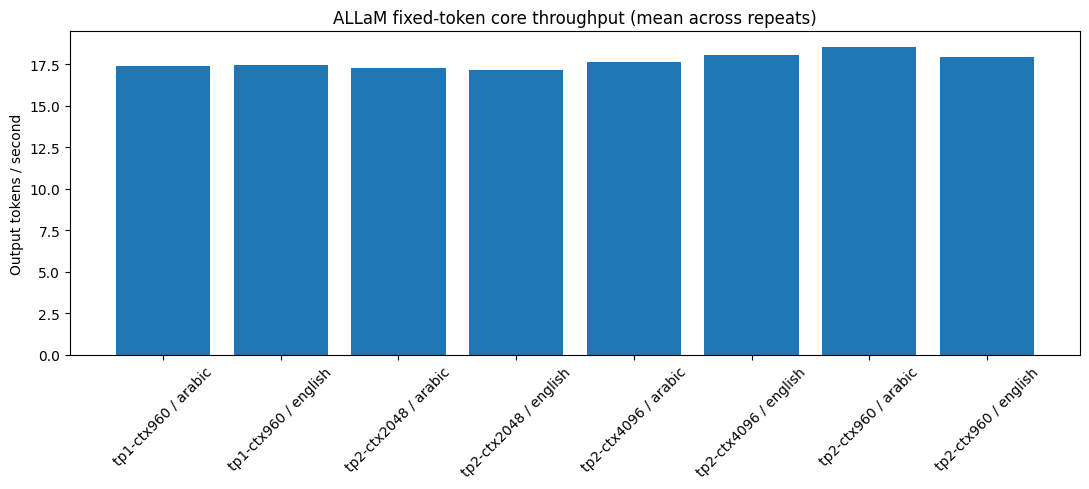

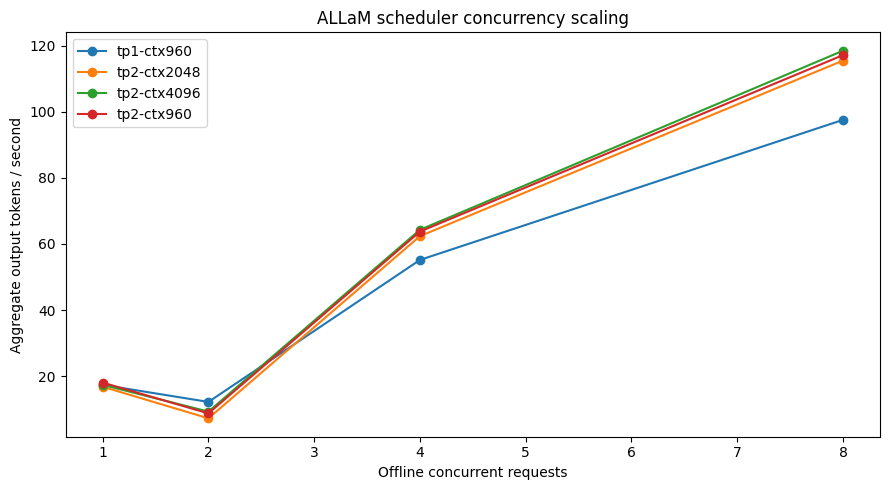

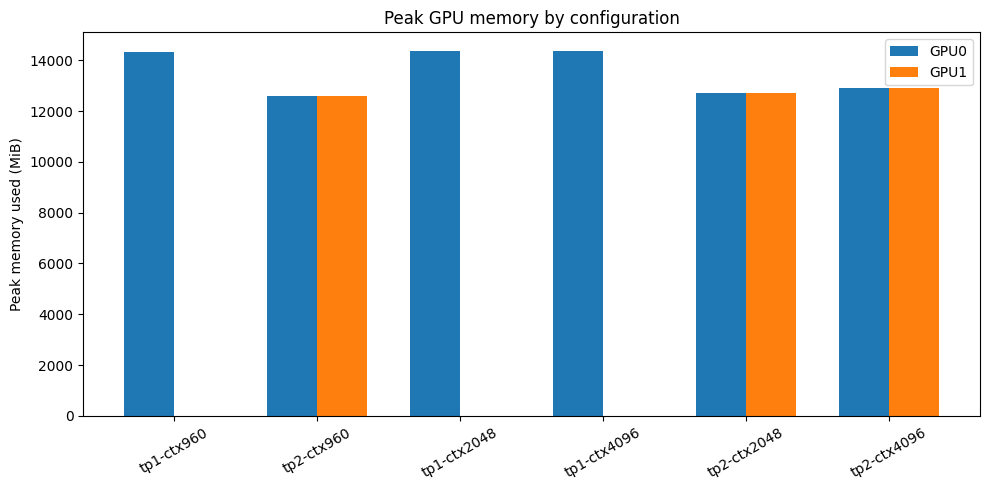

In [18]:
# ============================================================
# STEP 11 — Research plots
# ============================================================

import matplotlib.pyplot as plt

# 1) Core output throughput.
if len(core_summary):
    plot_df = core_summary.copy()
    labels = plot_df["tag"] + " / " + plot_df["language"]
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.bar(labels, plot_df["output_tps_mean"])
    ax.set_ylabel("Output tokens / second")
    ax.set_title("ALLaM fixed-token core throughput (mean across repeats)")
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "core-throughput.png", dpi=160)
    plt.show()

# 2) Concurrency scaling.
if len(concurrency_df):
    fig, ax = plt.subplots(figsize=(9, 5))
    for tag, g in concurrency_df.groupby("tag"):
        g = g.sort_values("concurrency")
        ax.plot(g["concurrency"], g["output_tokens_per_s"], marker="o", label=tag)
    ax.set_xlabel("Offline concurrent requests")
    ax.set_ylabel("Aggregate output tokens / second")
    ax.set_title("ALLaM scheduler concurrency scaling")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "concurrency-scaling.png", dpi=160)
    plt.show()

# 3) Peak memory by configuration (GPU0 + GPU1 shown separately).
if len(config_df):
    mem = config_df[["tag", "gpu0_peak_mem_mib", "gpu1_peak_mem_mib"]].copy()
    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(mem))
    width = 0.35
    ax.bar([i - width/2 for i in x], mem["gpu0_peak_mem_mib"], width=width, label="GPU0")
    ax.bar([i + width/2 for i in x], mem["gpu1_peak_mem_mib"], width=width, label="GPU1")
    ax.set_xticks(list(x))
    ax.set_xticklabels(mem["tag"], rotation=30)
    ax.set_ylabel("Peak memory used (MiB)")
    ax.set_title("Peak GPU memory by configuration")
    ax.legend()
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "peak-memory.png", dpi=160)
    plt.show()

## 12. Paper-informed bilingual efficiency view

The paper's tokenizer argument is about the amount of **text represented per token**. The benchmark matrix above intentionally normalizes by tokens for systems fairness.

This cell puts the two views side by side:

- **word/text view:** tokenizer fertility diagnostic;
- **token view:** measured fixed-token inference.

Do not interpret this as a direct reproduction of Figure 3. The paper computed fertility over a random subsample of its training corpora; this notebook uses only the explicitly displayed diagnostic passages.

In [19]:
# ============================================================
# STEP 12 — Bilingual interpretation table
# ============================================================

bilingual_rows = []

for lang in ("english", "arabic"):
    fert = fertility_df[fertility_df["sample"] == lang]
    tokens_per_word = float(fert.iloc[0]["tokens_per_word"]) if len(fert) else None

    measured = core_summary[core_summary["language"] == lang] if len(core_summary) else pd.DataFrame()
    for _, r in measured.iterrows():
        bilingual_rows.append(
            {
                "tag": r["tag"],
                "language": lang,
                "diagnostic_tokens_per_word": tokens_per_word,
                "fixed_token_output_tps_mean": r["output_tps_mean"],
                "fixed_token_ttft_p50_mean_s": r["ttft_p50_mean_s"],
            }
        )

bilingual_df = pd.DataFrame(bilingual_rows)
display(bilingual_df)
bilingual_df.to_csv(EVIDENCE_DIR / "bilingual-efficiency-view.csv", index=False)

,tag,language,diagnostic_tokens_per_word,fixed_token_output_tps_mean,fixed_token_ttft_p50_mean_s
0,tp1-ctx960,english,1.2414,17.461133,NaN
1,tp2-ctx2048,english,1.2414,17.132449,NaN
2,tp2-ctx4096,english,1.2414,18.039906,NaN
3,tp2-ctx960,english,1.2414,17.934799,NaN
4,tp1-ctx960,arabic,1.2333,17.408365,NaN
5,tp2-ctx2048,arabic,1.2333,17.245812,NaN
6,tp2-ctx4096,arabic,1.2333,17.632523,NaN
7,tp2-ctx960,arabic,1.2333,18.541052,NaN


## 13. Deterministic interpretation rules

This notebook avoids an unsupported "winner" label. It reports measured relationships:

- Which configurations passed, failed, or were resource-gated?
- For configurations where both TP=1 and TP=2 passed at the same context, what is the percentage throughput delta?
- Did throughput increase with scheduler concurrency?
- Was full 4096 context empirically exercised?
- Did both English and Arabic chat sanity checks return non-empty text?
- Did every passing T4 configuration select `TRITON_ATTN`?

These statements are generated from the evidence files below.

In [20]:
# ============================================================
# STEP 13 — Deterministic findings
# ============================================================

findings = []

for _, row in config_df.iterrows():
    findings.append(
        {
            "type": "configuration_status",
            "tag": row["tag"],
            "status": row["status"],
            "tp": int(row["tp"]),
            "max_model_len": int(row["max_model_len"]),
        }
    )

# Same-context TP comparison, only when both exist and pass.
for ctx in sorted(config_df["max_model_len"].unique()):
    passed_tags = config_df[
        (config_df["max_model_len"] == ctx) & (config_df["status"] == "PASS")
    ]["tag"].tolist()

    tp1_tag = f"tp1-ctx{ctx}"
    tp2_tag = f"tp2-ctx{ctx}"

    if tp1_tag in passed_tags and tp2_tag in passed_tags and len(core_summary):
        a = core_summary[(core_summary["tag"] == tp1_tag) & (core_summary["language"] == "english")]
        b = core_summary[(core_summary["tag"] == tp2_tag) & (core_summary["language"] == "english")]
        if len(a) and len(b):
            tp1 = float(a.iloc[0]["output_tps_mean"])
            tp2 = float(b.iloc[0]["output_tps_mean"])
            delta_pct = ((tp2 - tp1) / tp1 * 100.0) if tp1 else None
            findings.append(
                {
                    "type": "tp_throughput_delta",
                    "max_model_len": int(ctx),
                    "language": "english",
                    "tp1_output_tps_mean": tp1,
                    "tp2_output_tps_mean": tp2,
                    "tp2_vs_tp1_pct": delta_pct,
                }
            )

# Chat sanity.
for s in matrix_summaries:
    child = s.get("child_result")
    if not child:
        continue
    chats = child.get("chat_sanity", [])
    findings.append(
        {
            "type": "chat_sanity",
            "tag": s["tag"],
            "nonempty_responses": sum(bool((x.get("text") or "").strip()) for x in chats),
            "expected_responses": 4,
            "pass": len(chats) == 4 and all((x.get("text") or "").strip() for x in chats),
        }
    )

findings_path = EVIDENCE_DIR / "deterministic-findings.json"
findings_path.write_text(
    json.dumps(findings, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

print(json.dumps(findings, ensure_ascii=False, indent=2))
print("Saved:", findings_path)

[
  {
    "type": "configuration_status",
    "tag": "tp1-ctx960",
    "status": "PASS",
    "tp": 1,
    "max_model_len": 960
  },
  {
    "type": "configuration_status",
    "tag": "tp2-ctx960",
    "status": "PASS",
    "tp": 2,
    "max_model_len": 960
  },
  {
    "type": "configuration_status",
    "tag": "tp1-ctx2048",
    "status": "RESOURCE_GATED",
    "tp": 1,
    "max_model_len": 2048
  },
  {
    "type": "configuration_status",
    "tag": "tp1-ctx4096",
    "status": "RESOURCE_GATED",
    "tp": 1,
    "max_model_len": 4096
  },
  {
    "type": "configuration_status",
    "tag": "tp2-ctx2048",
    "status": "PASS",
    "tp": 2,
    "max_model_len": 2048
  },
  {
    "type": "configuration_status",
    "tag": "tp2-ctx4096",
    "status": "PASS",
    "tp": 2,
    "max_model_len": 4096
  },
  {
    "type": "tp_throughput_delta",
    "max_model_len": 960,
    "language": "english",
    "tp1_output_tps_mean": 17.46113318375008,
    "tp2_output_tps_mean": 17.93479948797898,
    "t

## 14. Evidence manifest and checksums

The notebook ends by hashing the research artifacts. This mirrors the evidence discipline used elsewhere in `kaggle-vllm`: raw logs remain the source of truth; aggregate tables and plots are derived artifacts.

Recommended files to preserve when saving the Kaggle version:

- `allam-characterization/evidence/matrix-summary.json`
- `allam-characterization/evidence/config-summary.csv`
- `allam-characterization/evidence/benchmark-rows.csv`
- `allam-characterization/evidence/core-repeat-summary.csv`
- `allam-characterization/evidence/capacity-probes.csv`
- `allam-characterization/evidence/concurrency-scaling.csv`
- `allam-characterization/evidence/tokenizer-fertility.json`
- `allam-characterization/evidence/deterministic-findings.json`
- every `runs/*.json`, `runs/*.log`, and `runs/*-gpu-telemetry.json`
- generated plots
- strict doctor output

### Claim boundary

A successful run can support claims about this **specific** checkpoint, runtime, hardware allocation and benchmark protocol. It does not reproduce the ALLaM paper's training results, quality benchmarks, human evaluation, safety evaluation, or A100-scale performance.

In [21]:
# ============================================================
# STEP 14 — Checksummed evidence manifest
# ============================================================

def sha256_file(path, chunk_size=8 * 1024 * 1024):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        while True:
            b = f.read(chunk_size)
            if not b:
                break
            h.update(b)
    return h.hexdigest()

artifact_paths = sorted(
    [
        p
        for p in RESEARCH_ROOT.rglob("*")
        if p.is_file()
        and p.name != "evidence-manifest.json"
    ]
)

manifest_rows = []
for p in artifact_paths:
    manifest_rows.append(
        {
            "path": str(p.relative_to(RESEARCH_ROOT)),
            "bytes": p.stat().st_size,
            "sha256": sha256_file(p),
        }
    )

evidence_manifest = {
    "model_id": MODEL_ID,
    "model_commit": MODEL_COMMIT,
    "internal_version": EXPECTED_INTERNAL_VERSION,
    "sdk": f"kaggle-vllm=={SDK_VERSION}",
    "matrix": MATRIX,
    "repeats": REPEATS,
    "core_prompt_tokens": CORE_PROMPT_TOKENS,
    "core_output_tokens": CORE_OUTPUT_TOKENS,
    "concurrency_levels": CONCURRENCY_LEVELS,
    "artifacts": manifest_rows,
}

evidence_manifest_path = RESEARCH_ROOT / "evidence-manifest.json"
evidence_manifest_path.write_text(
    json.dumps(evidence_manifest, ensure_ascii=False, indent=2) + "\n",
    encoding="utf-8",
)

print("Evidence manifest:", evidence_manifest_path)
print("Artifacts hashed:", len(manifest_rows))

print("\nFinal configuration outcomes:")
display(config_df[["tag", "status", "tp", "max_model_len", "engine_init_s"]])

Evidence manifest: /kaggle/working/allam-characterization/evidence-manifest.json
Artifacts hashed: 31

Final configuration outcomes:


,tag,status,tp,max_model_len,engine_init_s
0,tp1-ctx960,PASS,1,960,43.944196
1,tp2-ctx960,PASS,2,960,58.147127
2,tp1-ctx2048,RESOURCE_GATED,1,2048,NaN
3,tp1-ctx4096,RESOURCE_GATED,1,4096,NaN
4,tp2-ctx2048,PASS,2,2048,76.496099
5,tp2-ctx4096,PASS,2,4096,59.673462


# Interpretation guide

Use the outputs conservatively.

### Strong measured statements
Examples of statements that can be made when supported by the generated evidence:

- "`TP=2, context=4096` initialized successfully on this dual-T4 allocation."
- "The fixed `128→32` workload produced X output tokens/s averaged over 3 repeats."
- "TP=2 was Y% faster/slower than TP=1 under the same measured workload."
- "At concurrency 8, aggregate output throughput changed by Z% relative to concurrency 1."
- "The near-context 4032-token input plus controlled output completed successfully."
- "Arabic diagnostic text required N tokens/word versus M for English on the deployed tokenizer."

### Statements this notebook does not support
Do not turn these experiments into claims that:

- the model's Arabic quality is better/worse than another model;
- TP=2 is universally better than TP=1;
- Kaggle T4 performance represents A100 training performance;
- the ALLaM paper's MMLU/ACVA/MT-Bench/human-evaluation scores were reproduced;
- a tiny fertility sample reproduces Figure 3;
- 4096 configuration success proves every 4096-token workload is stable.

A useful follow-up after this offline study is an **online serving notebook** using the vLLM OpenAI-compatible server and controlled request arrival/concurrency, so TTFT/TPOT/throughput can be studied under a true serving workload.

In [24]:
!zip -rq /kaggle/working/allam-characterization.zip /kaggle/working/allam-characterization